# Features do dataset4

Estas variáveis descrevem como foram criadas e utilizadas nas simulações.

* **`GAP_PORCENTAGEM`**
    
    * **Cálculo:** $\frac{\text{Abertura Hoje} - \text{Fechamento Ontem}}{\text{Fechamento Ontem}} \times 100$

* **`GAP_ALTA`**
    * **O que é:** Uma variável binária (0 ou 1) que diz a direção do pulo.
    * **Cálculo:** Se `Abertura > Fechamento Ontem`, então **1** (Gap de Alta). Senão, **0** (Gap de Baixa).

* **`GAP_NA_FAIXA_IDEAL`**
    * **O que é:** Uma variável binária (0 ou 1) que indica se o tamanho do gap está dentro de uma zona de alta probabilidade de fechamento.
    * **Cálculo:** Baseado na Análise Exploratória, o intervalo com maior probabilidade de fechar está entre -250 e +250 pontos.

* **`DIAS_DESDE_ULTIMO_GAP`**
    * **Cálculo:** Contagem de dias consecutivos em que não houve um gap significativo.(>0,1%)

* **`FORCA_ABERTURA_10MIN`**
    * **O que é:** A direção e intensidade que o mercado tomou logo após os 10 primeiros minutos.
    * **Cálculo:** $\frac{\text{Preço às 09:10} - \text{Preço de Abertura}}{\text{Preço de Abertura}}$

* **`DIVERGENCIA_ABERTURA`**
    * **O que é:** Uma variável binária que identifica um comportamento de exaustão ou rejeição do movimento inicial.
    * **Lógica:**
        * Se (Gap é Alta **E** Força 10min é Negativa) = **1**
        * Se (Gap é Baixa **E** Força 10min é Positiva) = **1**
        * Caso contrário (vão para o mesmo lado) = **0**

* **`VOLATILIDADE_ANTERIOR`**
    * **O que é:** O tamanho da oscilação do dia anterior (amplitude).
    * **Cálculo:** $\frac{\text{Máxima Ontem} - \text{Mínima Ontem}}{\text{Fechamento Ontem}}$

* **`TENDENCIA_VOLATILIDADE` (TEND_Aumentando, TEND_Diminuindo, TEND_Estável)**
    * **O que é:** A derivada da volatilidade. O mercado está ficando mais nervoso ou mais calmo comparado aos dias anteriores?
    * **Cálculo:** Compara a `VOLATILIDADE_ANTERIOR` com a `Média da Volatilidade dos últimos X dias` (ex: 5 ou 20).
        * Se `Volatilidade Ontem > Média`: **Aumentando**.
        * Se `Volatilidade Ontem < Média`: **Diminuindo**.


* **`ALVO_FECHOU_GAP_30MIN`**
    * **O que é:** É o alvo que o modelo tenta aprender a prever.
    * **Lógica:**
        1.  Pega o preço de `Fechamento de Ontem`.
        2.  Olha todos os preços (candles de 1 min) das **09:00 até as 09:30** de hoje.
        3.  Se algum preço tocou ou ultrapassou o `Fechamento de Ontem` -> **1** (Verdadeiro/Fechou).
        4.  Se o tempo acabou (09:30) e o preço nunca tocou lá -> **0** (Falso/Não Fechou).

### Nota sobre o sufixo `_norm`

Você viu muitas colunas terminando em `_norm` (ex: `GAP_PORCENTAGEM_norm`).
Isso significa que a coluna passou por um processo de **Padronização/normalização** antes de entrar no arquivo final.
* **Cálculo:** $\frac{\text{(Valor} - \text{Média)}}{\text{Desvio Padrão}}$


Iniciando a execução do pipeline...

Baixando dataset de: https://raw.githubusercontent.com/Juliana001/Datascience-para-Mercado-Financeiro---Projeto-final/refs/heads/main/Datsets/dataset4.csv...
Índice de data configurado com sucesso.
Dataset carregado! Shape: (602, 11)

--- TREINAMENTO DO MODELO ---
Treino (Passado): 451 dias
Teste (Futuro):   151 dias
Variância Explicada pelo PCA (5D): 72.1%
Treinando Random Forest...

--- EXECUTANDO BACKTEST REALISTA ---
Usando coluna 'GAP_PORCENTAGEM_norm' para dimensionar o lucro/perda.

RELATÓRIO FINAL (Limiar 55%)
Período: 2022-09-12 a 2023-04-19
Capital Inicial: R$ 10,000.00
Saldo Final:     R$ 12,353.63
Lucro Líquido:   R$ 2,353.63 (23.54%)
------------------------------
Trades: 33 | Acertos: 29 (87.9%)
Maior Ganho: R$ 109.09
Maior Perda: R$ -100.19
Freq. Média Ops: 1 a cada 4.6 dias
------------------------------
Profit Factor: 7.06
Expectancy: R$ 71.32 / trade
Max Perdas Seguidas: 2
Índice de Sharpe: 3.94
Max Drawdown: R$ -196.05
Tempo de Re

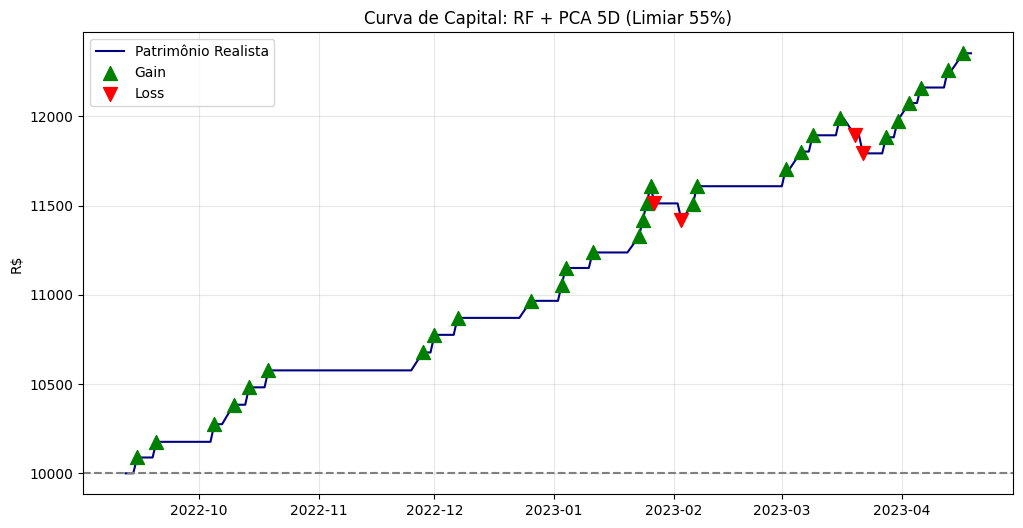

In [15]:
# @title Backtest (Random Forest com PCA5D e limiar de 55%)
# Este notebook reproduz a estratégia quantitativa de fechamento de gaps no Mini-Índice.

print("Iniciando a execução do pipeline...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import requests
import io

# ==============================================================================
# 1. CARREGAMENTO DOS DADOS (Direto do GitHub)
# ==============================================================================
url_dataset = "https://raw.githubusercontent.com/Juliana001/Datascience-para-Mercado-Financeiro---Projeto-final/refs/heads/main/Datsets/dataset4.csv"

print(f"\nBaixando dataset de: {url_dataset}...")

try:
    s = requests.get(url_dataset).content
    df = pd.read_csv(io.StringIO(s.decode('utf-8')))

    # Tratamento de Data
    if 'DATE' in df.columns:
        df['DATE'] = pd.to_datetime(df['DATE'])
        df = df.sort_values('DATE')
        df = df.set_index('DATE')
        print("Índice de data configurado com sucesso.")

    print(f"Dataset carregado! Shape: {df.shape}")

except Exception as e:
    print(f"ERRO FATAL ao baixar dados: {e}")
    raise

# ==============================================================================
# 2. CONFIGURAÇÃO DA ESTRATÉGIA
# ==============================================================================
TARGET = 'ALVO_FECHOU_GAP_30MIN'
CAPITAL_INICIAL = 10000.00
CUSTO_POR_OPERACAO = 5.00
LIMIAR_CONFIANCA = 0.55  # Limiar Seletivo
VALOR_PONTO = 0.20       # Mini-Índice
INDICE_REFERENCIA = 110000.0
RISK_FREE_RATE_DAILY = (1 + 0.13)**(1/252) - 1

# Verificar Alvo
if TARGET not in df.columns:
    raise KeyError(f"Coluna alvo '{TARGET}' não encontrada no dataset.")

# Separar X e y
y = df[TARGET]
X = df.drop(columns=[TARGET])

# ==============================================================================
# 3. TREINAMENTO (Random Forest + PCA 5D)
# ==============================================================================
print("\n--- TREINAMENTO DO MODELO ---")

# Divisão Cronológica (75% Treino / 25% Teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

print(f"Treino (Passado): {len(X_train)} dias")
print(f"Teste (Futuro):   {len(X_test)} dias")

# Pipeline: Normalização -> PCA 5D -> Random Forest
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

print(f"Variância Explicada pelo PCA (5D): {np.sum(pca.explained_variance_ratio_):.1%}")

print("Treinando Random Forest...")
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train_pca, y_train)

# ==============================================================================
# 4. SIMULAÇÃO REALISTA (BACKTEST)
# ==============================================================================
print("\n--- EXECUTANDO BACKTEST REALISTA ---")

# Previsões
probs = model.predict_proba(X_test_pca)[:, 1]
previsoes = (probs > LIMIAR_CONFIANCA).astype(int)
reais = y_test.values
datas = y_test.index

# Identificar coluna de gap para cálculo financeiro
col_gap = 'GAP_PORCENTAGEM_norm'
if col_gap not in df.columns:
    # Tenta fallback
    possiveis = [c for c in df.columns if 'GAP' in c and 'PORC' in c]
    col_gap = possiveis[0] if possiveis else None

if col_gap:
    print(f"Usando coluna '{col_gap}' para dimensionar o lucro/perda.")
    dados_teste = df.loc[datas].copy()
else:
    print("AVISO: Coluna de Gap% não encontrada. Usando valor fixo médio.")
    dados_teste = pd.DataFrame(index=datas)
    dados_teste['GAP_FIXO'] = 0.5
    col_gap = 'GAP_FIXO'

# Loop de Simulação
saldo = [CAPITAL_INICIAL]
carteira = 0
historico_trades = []
retornos_diarios = []

for t in range(len(previsoes)):
    d = previsoes[t]
    resultado_real = reais[t]

    # Estimativa do Valor do Gap (Realista)
    pct_gap = abs(dados_teste.iloc[t][col_gap])
    pontos_gap = INDICE_REFERENCIA * (pct_gap / 100.0)
    valor_trade = pontos_gap * VALOR_PONTO

    if valor_trade < 20.0: valor_trade = 20.0 # Trava mínima

    lucro_do_dia = 0.0

    # Estratégia: Operar se Prob > 55%
    if d == 1 and abs(carteira) < 1:
        carteira = 1
        if resultado_real == 1:
            res_bruto = valor_trade  # Gain
            tipo = "GAIN"
        else:
            res_bruto = -valor_trade # Loss
            tipo = "LOSS"

        lucro_do_dia = res_bruto - CUSTO_POR_OPERACAO

        historico_trades.append({
            'Dia': datas[t],
            'Tipo': tipo,
            'Liquido': lucro_do_dia,
            'Saldo': saldo[-1] + lucro_do_dia
        })
        carteira = 0

    novo_saldo = saldo[-1] + lucro_do_dia

    # Cálculo para Sharpe
    if saldo[-1] > 0: retornos_diarios.append(lucro_do_dia / saldo[-1])
    else: retornos_diarios.append(0)

    saldo.append(novo_saldo)

# ==============================================================================
# 5. RELATÓRIO FINAL E GRÁFICO
# ==============================================================================
saldo_final = saldo[-1]
lucro_total = saldo_final - CAPITAL_INICIAL
num_trades = len(historico_trades)

if num_trades > 0:
    df_trades = pd.DataFrame(historico_trades)
    wins = len(df_trades[df_trades['Tipo']=='GAIN'])
    losses = len(df_trades[df_trades['Tipo']=='LOSS'])
    acc = wins/num_trades

    avg_gain = df_trades[df_trades['Tipo']=='GAIN']['Liquido'].mean()
    avg_loss = df_trades[df_trades['Tipo']=='LOSS']['Liquido'].mean()

    if abs(df_trades[df_trades['Tipo']=='LOSS']['Liquido'].sum()) > 0:
        profit_factor = df_trades[df_trades['Tipo']=='GAIN']['Liquido'].sum() / abs(df_trades[df_trades['Tipo']=='LOSS']['Liquido'].sum())
    else:
        profit_factor = float('inf')

    expectancy = (acc * avg_gain) - ((1-acc) * abs(avg_loss))

    # Max Drawdown
    curve = pd.Series(saldo)
    peak = curve.cummax()
    drawdown = (curve - peak).min()

    # Recovery Time
    dd_curve = (curve - peak) / peak
    is_down = dd_curve < 0
    if is_down.any():
        max_recovery = is_down.groupby((is_down != is_down.shift()).cumsum()).cumsum()[is_down].max()
    else:
        max_recovery = 0

else:
    wins=losses=acc=avg_gain=avg_loss=profit_factor=sharpe=drawdown=max_recovery=0
    expectancy = 0

# Sharpe
s_ret = pd.Series(retornos_diarios)
std_ret = s_ret.std()
sharpe = ((s_ret.mean() - RISK_FREE_RATE_DAILY) / std_ret) * np.sqrt(252) if std_ret > 0 else 0

# Max Perdas Seguidas
if num_trades > 0:
    is_loss = df_trades['Tipo'] == 'LOSS'
    consecutive = is_loss.groupby((is_loss != is_loss.shift()).cumsum()).cumsum()
    max_consec = consecutive[is_loss].max() if losses > 0 else 0
else:
    max_consec = 0

print("\n" + "="*50)
print(f"RELATÓRIO FINAL (Limiar {LIMIAR_CONFIANCA:.0%})")
print("="*50)
try:
    print(f"Período: {datas[0].date()} a {datas[-1].date()}")
except: pass
print(f"Capital Inicial: R$ {CAPITAL_INICIAL:,.2f}")
print(f"Saldo Final:     R$ {saldo_final:,.2f}")
print(f"Lucro Líquido:   R$ {lucro_total:,.2f} ({lucro_total/CAPITAL_INICIAL:.2%})")
print("-" * 30)
print(f"Trades: {num_trades} | Acertos: {wins} ({acc:.1%})")
print(f"Maior Ganho: R$ {df_trades['Liquido'].max():.2f}" if num_trades > 0 else "0.00")
print(f"Maior Perda: R$ {df_trades['Liquido'].min():.2f}" if num_trades > 0 else "0.00")
print(f"Freq. Média Ops: 1 a cada {len(datas)/num_trades:.1f} dias" if num_trades > 0 else "-")
print("-" * 30)
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Expectancy: R$ {expectancy:.2f} / trade")
print(f"Max Perdas Seguidas: {int(max_consec)}")
print(f"Índice de Sharpe: {sharpe:.2f}")
print(f"Max Drawdown: R$ {drawdown:,.2f}")
print(f"Tempo de Recuperação: {int(max_recovery)} dias")
print("="*50)

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(datas, saldo[1:], label='Patrimônio Realista', color='navy')
plt.axhline(CAPITAL_INICIAL, color='gray', linestyle='--')

if num_trades > 0:
    plt.scatter(df_trades[df_trades['Tipo']=='GAIN']['Dia'],
                df_trades[df_trades['Tipo']=='GAIN']['Saldo'],
                color='green', marker='^', s=100, zorder=5, label='Gain')
    plt.scatter(df_trades[df_trades['Tipo']=='LOSS']['Dia'],
                df_trades[df_trades['Tipo']=='LOSS']['Saldo'],
                color='red', marker='v', s=100, zorder=5, label='Loss')

plt.title(f'Curva de Capital: RF + PCA 5D (Limiar {LIMIAR_CONFIANCA:.0%})')
plt.ylabel('R$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()